# HVAC Electricity Forecasting - Eagle Education Paul

**Goal:** Train a Random Forest ML model to forecast hourly electricity demand for `Eagle_education_Paul`
(Education Classroom, 4,008 m2, Eagle site), then use predictions to regulate HVAC setpoints.

**Hardware:** ESP32 + DHT22 (temp/humidity), BMP280 (pressure), MQ-135 (CO2/air quality),
PIR HC-SR501 (occupancy), Relay Module (HVAC control).

| Item | Detail |
|---|---|
| Building | Eagle_education_Paul |
| Usage | Education - Classroom |
| Area | 4,008 m2 / 43,143 ft2 |
| Dataset rows | 17,365 hourly readings |
| Target variable | electricity (kWh) |
| Model | Random Forest (Baseline + Tuned) |


## 0. Install & Import Libraries


In [1]:
import subprocess, sys
for p in ['pandas','numpy','matplotlib','seaborn','scikit-learn','joblib','scipy']:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])

import warnings; warnings.filterwarnings('ignore')
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#c9d1d9','ytick.color':'#c9d1d9','text.color':'#c9d1d9',
    'grid.color':'#21262d','grid.linestyle':'--',
    'legend.facecolor':'#161b22','legend.edgecolor':'#30363d',
    'figure.titlesize':14,'axes.titlesize':12,'axes.labelsize':10,
})
ACCENT, ACCENT2, WARN = '#58a6ff', '#3fb950', '#f78166'

import sklearn
print('Libraries loaded successfully')
print(f'  pandas   {pd.__version__}')
print(f'  numpy    {np.__version__}')
print(f'  sklearn  {sklearn.__version__}')


Libraries loaded successfully
  pandas   2.3.3
  numpy    2.4.2
  sklearn  1.9.0


## 1. Load Datasets


In [3]:
DATA_DIR   = os.getcwd()
metadata   = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
ml_dataset = pd.read_csv(os.path.join(DATA_DIR, 'ml_dataset.csv'), parse_dates=['timestamp'])

print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'  metadata   : {metadata.shape[0]:,} buildings x {metadata.shape[1]} attributes')
print(f'  ml_dataset : {ml_dataset.shape[0]:,} hourly rows x {ml_dataset.shape[1]} features')
print()

TARGET_BUILDING = 'Eagle_education_Paul'
bldg = metadata[metadata['building_id'] == TARGET_BUILDING].iloc[0]
print('='*55)
print(f'BUILDING  : {bldg["building_id"]}')
print(f'Site      : {bldg["site_id"]}')
print(f'Usage     : {bldg["primaryspaceusage"]} - {bldg["sub_primaryspaceusage"]}')
print(f'Area      : {bldg["sqm"]} m2  /  {bldg["sqft"]} ft2')
print(f'Timezone  : {bldg["timezone"]}')
print(f'Utilities : Electricity={bldg["electricity"]}, HotWater={bldg["hotwater"]}, Chilled={bldg["chilledwater"]}')
print('='*55)

print('\nML Dataset Head:')
display(ml_dataset.head())

print('\nData Types & Missing Values:')
info = pd.DataFrame({
    'dtype': ml_dataset.dtypes,
    'non_null': ml_dataset.notnull().sum(),
    'missing': ml_dataset.isnull().sum()
})
display(info)


DATASET OVERVIEW
  metadata   : 1,636 buildings x 32 attributes
  ml_dataset : 17,365 hourly rows x 15 features

BUILDING  : Eagle_education_Paul
Site      : Eagle
Usage     : Education - Classroom
Area      : 4008.1 m2  /  43143.0 ft2
Timezone  : US/Eastern
Utilities : Electricity=Yes, HotWater=Yes, Chilled=Yes

ML Dataset Head:


,timestamp,electricity,airTemperature,dewTemperature,cloudCoverage,seaLvlPressure,windDirection,windSpeed,hour,day_of_week,month,is_weekend,electricity_lag_1,electricity_lag_24,electricity_lag_168
0,2016-01-08 03:00:00,24.3296,2.2,-2.2,0.0,1022.0,0.0,0.0,3,4,1,0,24.3296,24.3296,22.3987
1,2016-01-08 04:00:00,24.3296,2.8,-1.1,0.0,1020.7,30.0,2.6,4,4,1,0,24.3296,24.3296,22.0125
2,2016-01-08 05:00:00,24.3296,2.2,-1.1,0.0,1021.1,350.0,2.6,5,4,1,0,24.3296,24.3296,19.6954
3,2016-01-08 06:00:00,24.3296,2.8,-0.6,0.0,1021.8,20.0,1.5,6,4,1,0,24.3296,24.3296,20.0816
4,2016-01-08 07:00:00,24.3296,2.2,-4.4,0.0,1021.8,20.0,2.6,7,4,1,0,24.3296,24.3296,19.6954



Data Types & Missing Values:


,dtype,non_null,missing
timestamp,datetime64[ns],17365,0
electricity,float64,17365,0
airTemperature,float64,17365,0
dewTemperature,float64,17365,0
cloudCoverage,float64,17365,0
seaLvlPressure,float64,17365,0
windDirection,float64,17365,0
windSpeed,float64,17365,0
hour,int64,17365,0
day_of_week,int64,17365,0


## 2. Exploratory Data Analysis


In [4]:
df = ml_dataset.copy()
print('Statistical Summary:')
display(df.describe().T.round(3))


Statistical Summary:


,count,mean,min,25%,50%,75%,max,std
timestamp,17365,2017-01-04 02:12:42.913907200,2016-01-08 03:00:00,2016-07-07 06:00:00,2017-01-04 04:00:00,2017-07-04 01:00:00,2017-12-31 23:00:00,NaN
electricity,17365.0,24.812133,0.0,19.6954,27.0329,32.4395,77.6231,12.910618
airTemperature,17365.0,13.311339,-15.6,5.6,13.9,21.7,35.6,10.036167
dewTemperature,17365.0,6.373585,-25.6,-1.7,7.2,15.6,25.6,10.562275
cloudCoverage,17365.0,1.33461,0.0,0.0,0.0,2.0,9.0,1.985997
seaLvlPressure,17365.0,1016.085799,982.6,1011.6,1016.0,1020.8,1041.6,7.573289
windDirection,17365.0,185.760841,0.0,70.0,210.0,290.0,360.0,121.905302
windSpeed,17365.0,3.079761,0.0,1.5,2.6,4.1,13.4,2.061959
hour,17365.0,11.503714,0.0,6.0,12.0,18.0,23.0,6.921055
day_of_week,17365.0,3.006795,0.0,1.0,3.0,5.0,6.0,2.000363


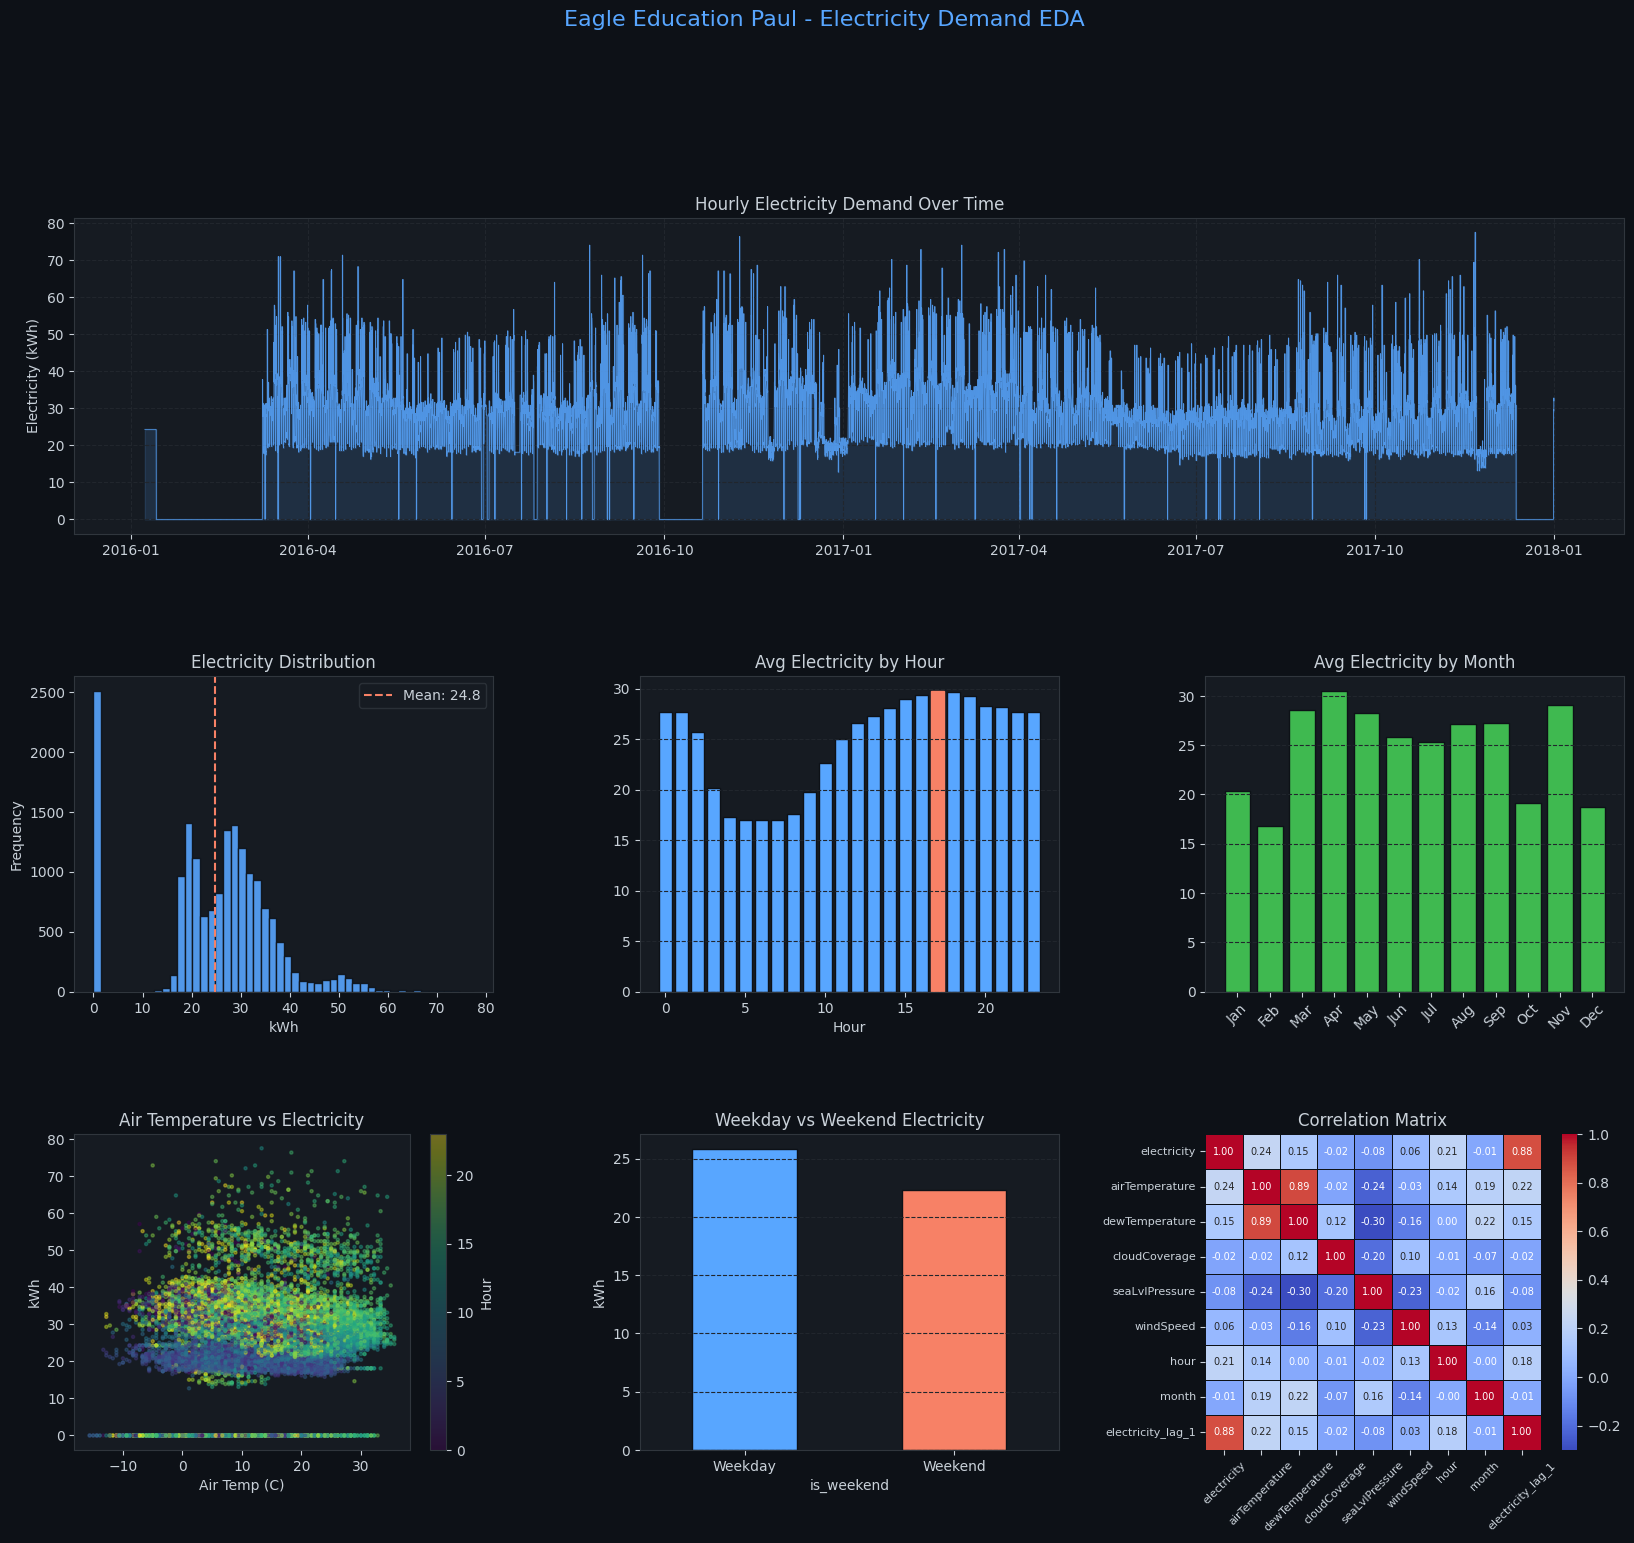

EDA plots saved to eda_plots.png


In [5]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Eagle Education Paul - Electricity Demand EDA', fontsize=16, color=ACCENT, y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['timestamp'], df['electricity'], color=ACCENT, linewidth=0.6, alpha=0.85)
ax1.fill_between(df['timestamp'], df['electricity'], alpha=0.15, color=ACCENT)
ax1.set_title('Hourly Electricity Demand Over Time')
ax1.set_ylabel('Electricity (kWh)'); ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(df['electricity'], bins=50, color=ACCENT, edgecolor='#0d1117', alpha=0.9)
ax2.axvline(df['electricity'].mean(), color=WARN, linestyle='--',
            label=f'Mean: {df["electricity"].mean():.1f}')
ax2.set_title('Electricity Distribution')
ax2.set_xlabel('kWh'); ax2.set_ylabel('Frequency'); ax2.legend()

ax3 = fig.add_subplot(gs[1, 1])
hourly_avg = df.groupby('hour')['electricity'].mean()
bars = ax3.bar(hourly_avg.index, hourly_avg.values, color=ACCENT, edgecolor='#0d1117')
bars[hourly_avg.idxmax()].set_color(WARN)
ax3.set_title('Avg Electricity by Hour')
ax3.set_xlabel('Hour'); ax3.grid(True, axis='y')

ax4 = fig.add_subplot(gs[1, 2])
monthly_avg = df.groupby('month')['electricity'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax4.bar([months[m-1] for m in monthly_avg.index], monthly_avg.values,
        color=ACCENT2, edgecolor='#0d1117')
ax4.set_title('Avg Electricity by Month')
ax4.tick_params(axis='x', rotation=45); ax4.grid(True, axis='y')

ax5 = fig.add_subplot(gs[2, 0])
sc = ax5.scatter(df['airTemperature'], df['electricity'],
                 c=df['hour'], cmap='viridis', alpha=0.4, s=5)
plt.colorbar(sc, ax=ax5, label='Hour')
ax5.set_title('Air Temperature vs Electricity')
ax5.set_xlabel('Air Temp (C)'); ax5.set_ylabel('kWh')

ax6 = fig.add_subplot(gs[2, 1])
df.groupby('is_weekend')['electricity'].mean().plot(
    kind='bar', ax=ax6, color=[ACCENT, WARN], edgecolor='#0d1117')
ax6.set_xticklabels(['Weekday','Weekend'], rotation=0)
ax6.set_title('Weekday vs Weekend Electricity')
ax6.set_ylabel('kWh'); ax6.grid(True, axis='y')

ax7 = fig.add_subplot(gs[2, 2])
num_cols = ['electricity','airTemperature','dewTemperature','cloudCoverage',
            'seaLvlPressure','windSpeed','hour','month','electricity_lag_1']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=ax7, cmap='coolwarm', annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.5, linecolor='#0d1117')
ax7.set_title('Correlation Matrix')
ax7.tick_params(axis='x', rotation=45, labelsize=8)
ax7.tick_params(axis='y', rotation=0,  labelsize=8)

plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('EDA plots saved to eda_plots.png')


## 3. Feature Engineering


In [6]:
df = ml_dataset.copy().sort_values('timestamp').reset_index(drop=True)

# --- Temporal ---
df['day_of_year']   = df['timestamp'].dt.dayofyear
df['quarter']       = df['timestamp'].dt.quarter
df['is_morning']    = ((df['hour'] >= 6)  & (df['hour'] < 12)).astype(int)
df['is_afternoon']  = ((df['hour'] >= 12) & (df['hour'] < 17)).astype(int)
df['is_evening']    = ((df['hour'] >= 17) & (df['hour'] < 21)).astype(int)
df['is_night']      = ((df['hour'] >= 21) | (df['hour'] <  6)).astype(int)
df['is_school_hrs'] = ((df['hour'] >= 8)  & (df['hour'] <= 17) & (df['is_weekend'] == 0)).astype(int)

# --- Cyclical encodings ---
df['hour_sin']  = np.sin(2 * np.pi * df['hour']        / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']        / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month']       / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']       / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] /  7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] /  7)

# --- Weather-derived ---
df['temp_dew_diff'] = df['airTemperature'] - df['dewTemperature']
df['feels_like']    = df['airTemperature'] - 0.4*(df['airTemperature']-10)*(1-df['dewTemperature']/100)
df['wind_chill']    = df['airTemperature'] - df['windSpeed'] * 0.7
df['pressure_diff'] = df['seaLvlPressure'] - df['seaLvlPressure'].mean()

# --- Rolling electricity ---
df['elec_roll_mean_3']  = df['electricity_lag_1'].rolling(3,  min_periods=1).mean().shift(1)
df['elec_roll_mean_6']  = df['electricity_lag_1'].rolling(6,  min_periods=1).mean().shift(1)
df['elec_roll_std_24']  = df['electricity_lag_1'].rolling(24, min_periods=1).std().shift(1).fillna(0)
df['elec_roll_max_24']  = df['electricity_lag_1'].rolling(24, min_periods=1).max().shift(1)

# --- Building constant ---
df['sqm'] = 4008.1

df = df.dropna().reset_index(drop=True)

new_feats = ['day_of_year','quarter','is_morning','is_afternoon','is_evening','is_night',
             'is_school_hrs','hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos',
             'temp_dew_diff','feels_like','wind_chill','pressure_diff',
             'elec_roll_mean_3','elec_roll_mean_6','elec_roll_std_24','elec_roll_max_24','sqm']
print('='*55)
print('FEATURE ENGINEERING COMPLETE')
print('='*55)
print(f'  Total rows  : {len(df):,}')
print(f'  Total cols  : {df.shape[1]}')
print(f'  New features: {len(new_feats)}')
for f in new_feats:
    print(f'    + {f}')


FEATURE ENGINEERING COMPLETE
  Total rows  : 17,364
  Total cols  : 37
  New features: 22
    + day_of_year
    + quarter
    + is_morning
    + is_afternoon
    + is_evening
    + is_night
    + is_school_hrs
    + hour_sin
    + hour_cos
    + month_sin
    + month_cos
    + dow_sin
    + dow_cos
    + temp_dew_diff
    + feels_like
    + wind_chill
    + pressure_diff
    + elec_roll_mean_3
    + elec_roll_mean_6
    + elec_roll_std_24
    + elec_roll_max_24
    + sqm


## 4. Train / Test Split (Chronological)


In [9]:
FEATURE_COLS = [
    'airTemperature','dewTemperature','cloudCoverage','seaLvlPressure','windDirection','windSpeed',
    'hour','day_of_week','month','is_weekend',
    'electricity_lag_1','electricity_lag_24','electricity_lag_168',
    'day_of_year','quarter',
    'is_morning','is_afternoon','is_evening','is_night','is_school_hrs',
    'hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos',
    'temp_dew_diff','feels_like','wind_chill','pressure_diff',
    'elec_roll_mean_3','elec_roll_mean_6','elec_roll_std_24','elec_roll_max_24',
    'sqm',
]
TARGET_COL = 'electricity'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
ts_test = df['timestamp'].iloc[split_idx:].reset_index(drop=True)

print('='*55)
print('TRAIN / TEST SPLIT  (chronological - no leakage)')
print('='*55)
print(f'  Training samples : {len(X_train):,}  ({100*len(X_train)/len(df):.0f}%)')
print(f'  Testing  samples : {len(X_test):,}  ({100*len(X_test)/len(df):.0f}%)')
print(f'  Features used    : {len(FEATURE_COLS)}')
print(f'  Train period     : {df["timestamp"].iloc[0]}  to  {df["timestamp"].iloc[split_idx-1]}')
print(f'  Test  period     : {df["timestamp"].iloc[split_idx]}  to  {df["timestamp"].iloc[-1]}')


TRAIN / TEST SPLIT  (chronological - no leakage)
  Training samples : 13,891  (80%)
  Testing  samples : 3,473  (20%)
  Features used    : 35
  Train period     : 2016-01-08 04:00:00  to  2017-08-09 05:00:00
  Test  period     : 2017-08-09 06:00:00  to  2017-12-31 23:00:00


## 5. Baseline Random Forest Model


In [10]:
print('Training Baseline Random Forest...')
rf_baseline = RandomForestRegressor(
    n_estimators=100, max_depth=None,
    min_samples_split=2, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)

print()
print('='*40)
print('BASELINE MODEL PERFORMANCE')
print('='*40)
print(f'MAE  : {mae_base:.4f}')
print(f'RMSE : {rmse_base:.4f}')
print(f'R2   : {r2_base:.4f}')


Training Baseline Random Forest...

BASELINE MODEL PERFORMANCE
MAE  : 3.2273
RMSE : 5.2518
R2   : 0.8161


## 6. Hyperparameter Tuning (RandomizedSearchCV)


In [11]:
param_dist = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.8],
    'bootstrap'        : [True, False],
}
print('Running RandomizedSearchCV (may take a few minutes)...')
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30, cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print()
print('Best parameters found:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:<25}: {v}')
print(f'  Best CV MAE : {-rf_search.best_score_:.4f}')


Running RandomizedSearchCV (may take a few minutes)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters found:
  bootstrap                : True
  max_depth                : 10
  max_features             : 0.5
  min_samples_leaf         : 7
  min_samples_split        : 12
  n_estimators             : 187
  Best CV MAE : 2.8283


## 7. Tuned Model Evaluation


In [13]:
rf_tuned    = rf_search.best_estimator_
y_pred_tune = rf_tuned.predict(X_test)

mae_tune  = mean_absolute_error(y_test, y_pred_tune)
rmse_tune = np.sqrt(mean_squared_error(y_test, y_pred_tune))
r2_tune   = r2_score(y_test, y_pred_tune)

print()
print('='*40)
print('TUNED MODEL PERFORMANCE:')
print('='*40)
print(f'MAE  : {mae_tune:.4f}')
print(f'RMSE : {rmse_tune:.4f}')
print(f'R2   : {r2_tune:.4f}')
print()
print('='*40)
print('MODEL COMPARISON')
print('='*40)
print(f'{"Metric":<8} {"Baseline":>10} {"Tuned":>10}')
print(f'{"MAE":<8} {mae_base:>10.4f} {mae_tune:>10.4f}')
print(f'{"RMSE":<8} {rmse_base:>10.4f} {rmse_tune:>10.4f}')
print(f'{"R2":<8} {r2_base:>10.4f} {r2_tune:>10.4f}')
print()
print('='*40)
print('IMPROVEMENT')
print('='*40)
mae_imp  = (mae_base  - mae_tune)  / mae_base  * 100
rmse_imp = (rmse_base - rmse_tune) / rmse_base * 100
r2_imp   = (r2_tune   - r2_base)   / abs(r2_base) * 100
print(f'MAE  improvement : {mae_imp:.2f}%')
print(f'RMSE improvement: {rmse_imp:.2f}%')
print(f'R2   improvement : {r2_imp:.2f}%')



TUNED MODEL PERFORMANCE:
MAE  : 2.8441
RMSE : 4.9640
R2   : 0.8357

MODEL COMPARISON
Metric     Baseline      Tuned
MAE          3.2273     2.8441
RMSE         5.2518     4.9640
R2           0.8161     0.8357

IMPROVEMENT
MAE  improvement : 11.87%
RMSE improvement: 5.48%
R2   improvement : 2.40%


## 8. Feature Importance



FEATURE IMPORTANCE
  feature                   importance
  electricity_lag_1           0.419829
  elec_roll_mean_3            0.238529
  elec_roll_mean_6            0.089491
  electricity_lag_24          0.076728
  elec_roll_std_24            0.037740
  elec_roll_max_24            0.037699
  hour_sin                    0.037332
  electricity_lag_168         0.028530
  hour                        0.006792
  hour_cos                    0.003098
  is_school_hrs               0.002882
  day_of_year                 0.002487
  temp_dew_diff               0.001799
  feels_like                  0.001603
  wind_chill                  0.001579
  dewTemperature              0.001423
  month_cos                   0.001299
  pressure_diff               0.001183
  windDirection               0.001157
  dow_sin                     0.001151
  seaLvlPressure              0.001129
  day_of_week                 0.001121
  airTemperature              0.000916
  windSpeed                   0.000863
  clo

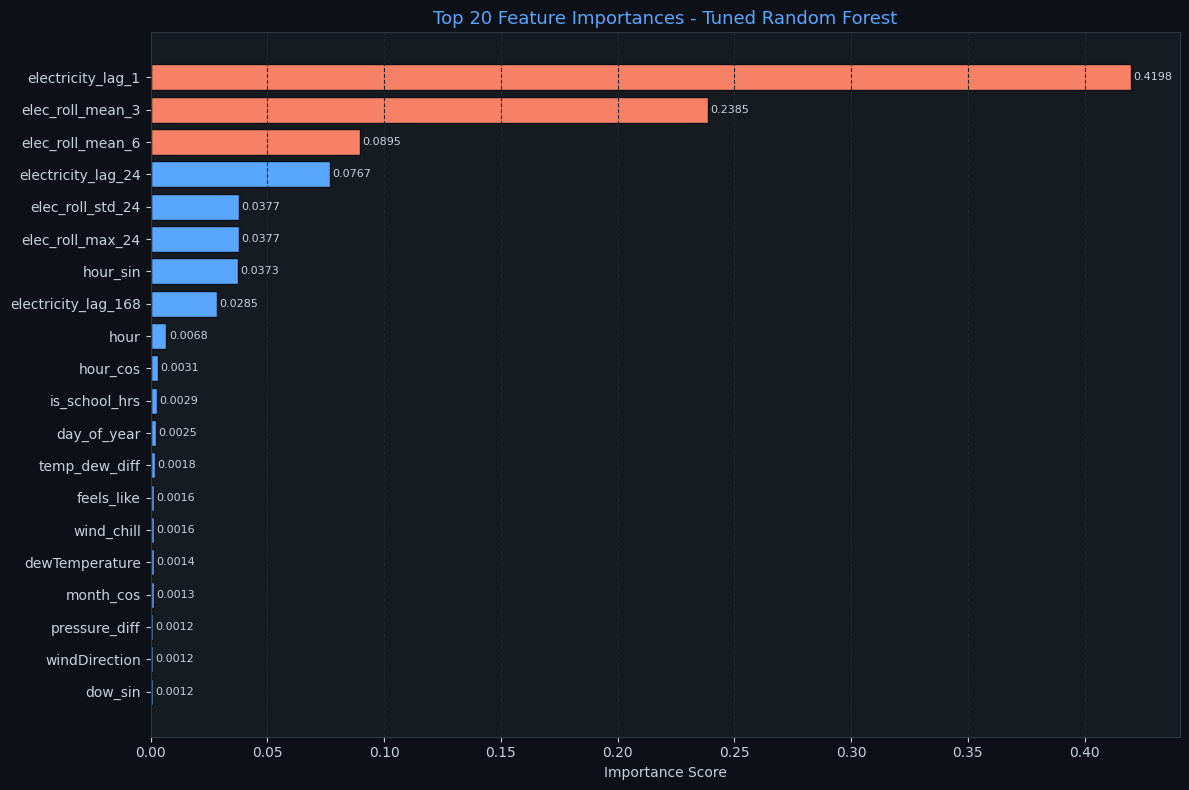

Feature importance saved to feature_importance.png


In [14]:
importances = pd.Series(rf_tuned.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print()
print('='*40)
print('FEATURE IMPORTANCE')
print('='*40)
print(f'  {"feature":<25} {"importance":>10}')
for feat, imp in importances.items():
    print(f'  {feat:<25} {imp:>10.6f}')

fig, ax = plt.subplots(figsize=(12, 8))
top_n  = importances.head(20)
colors = [WARN if i < 3 else ACCENT for i in range(len(top_n))]
ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1], edgecolor='#0d1117')
ax.set_title('Top 20 Feature Importances - Tuned Random Forest', fontsize=13, color=ACCENT)
ax.set_xlabel('Importance Score'); ax.grid(True, axis='x')
for bar, val in zip(ax.patches, top_n.values[::-1]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=8, color='#c9d1d9')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Feature importance saved to feature_importance.png')


## 9. Predictions vs Actual


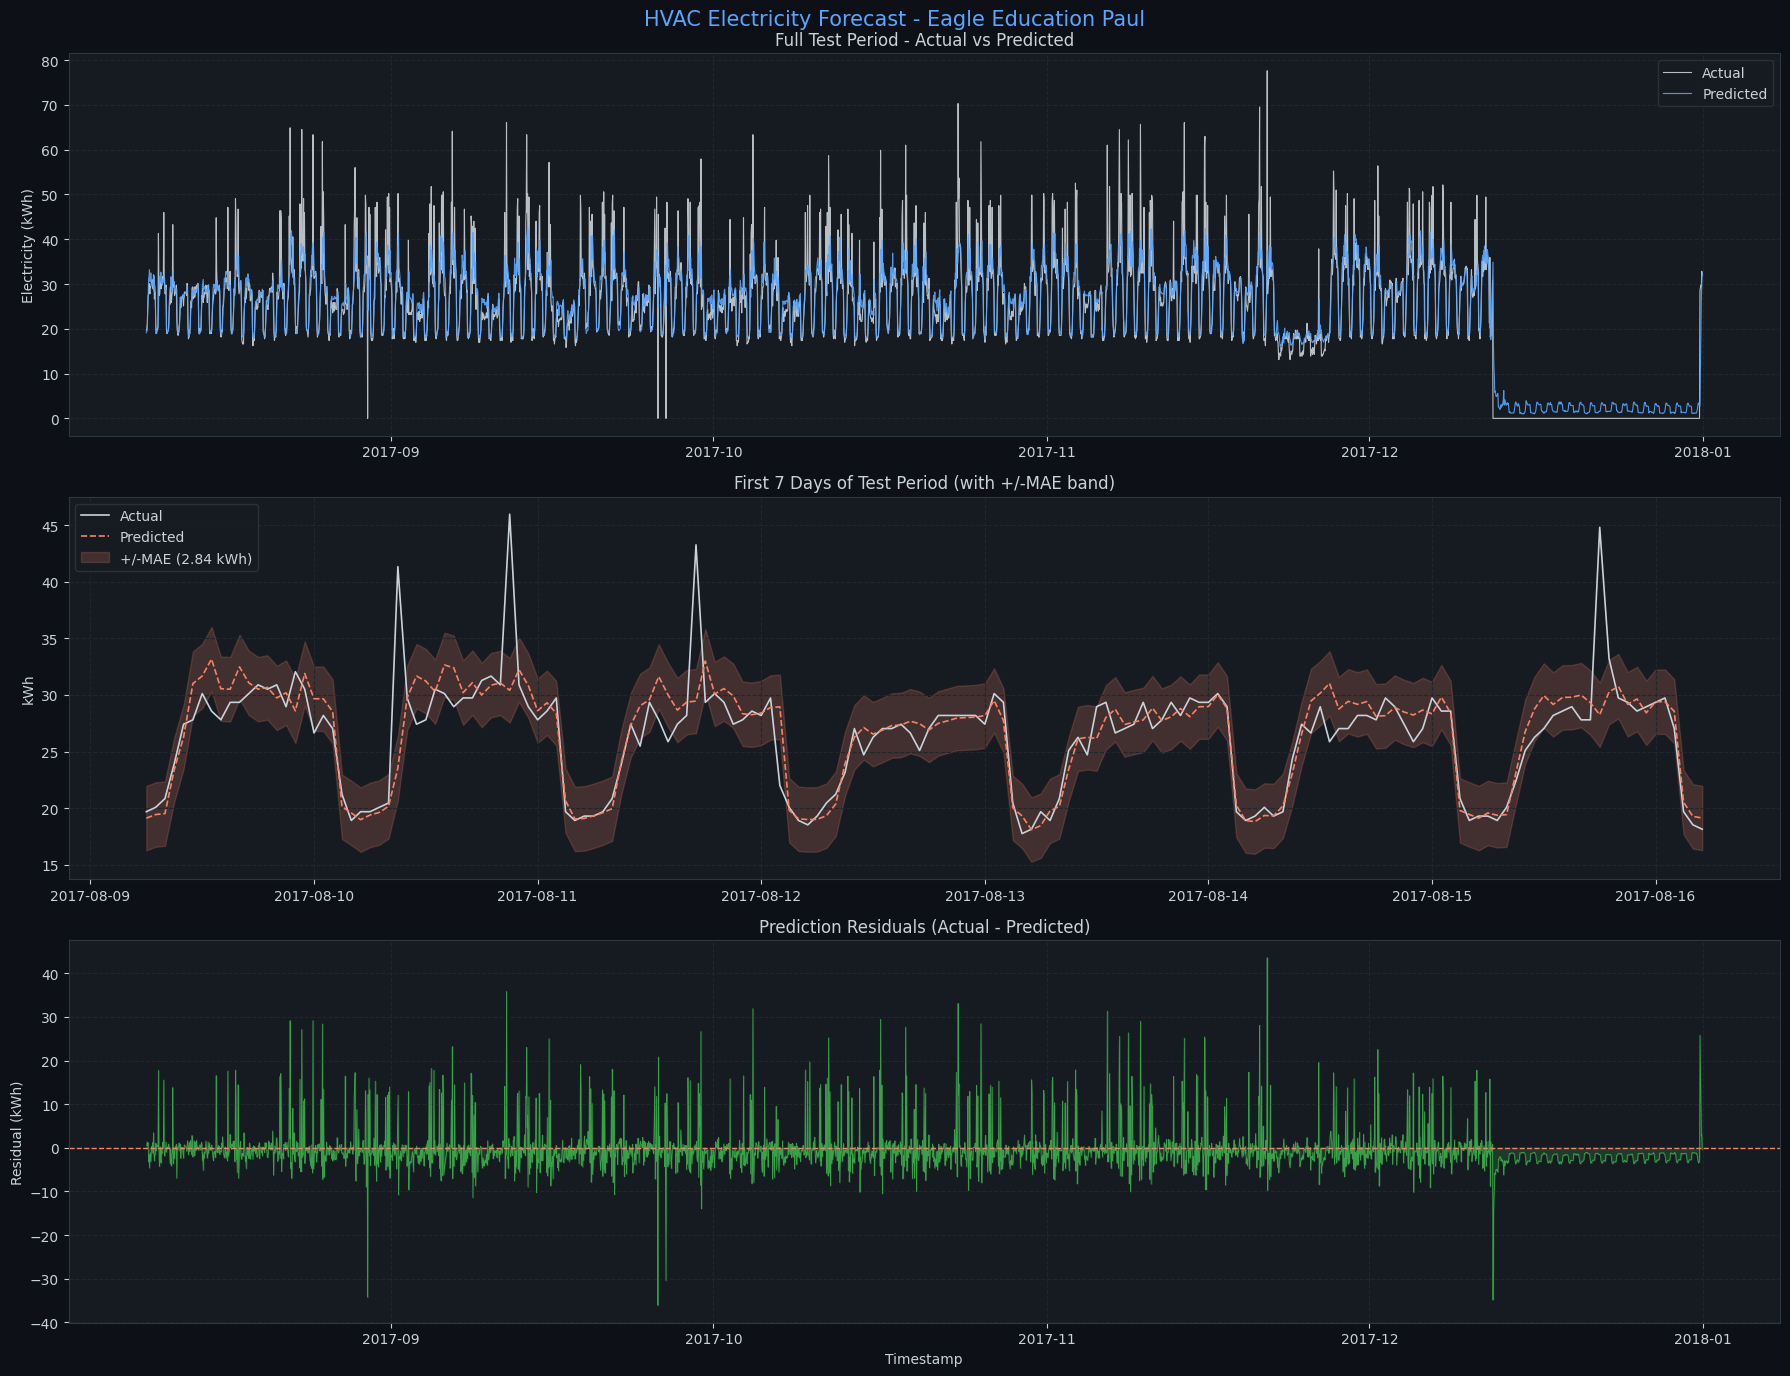

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('HVAC Electricity Forecast - Eagle Education Paul', fontsize=15, color=ACCENT)

ax = axes[0]
ax.plot(ts_test.values, y_test.values,  color='#c9d1d9', linewidth=0.8, label='Actual', alpha=0.9)
ax.plot(ts_test.values, y_pred_tune,    color=ACCENT,    linewidth=0.8, label='Predicted', alpha=0.9)
ax.set_title('Full Test Period - Actual vs Predicted')
ax.set_ylabel('Electricity (kWh)'); ax.legend(); ax.grid(True)

ax2 = axes[1]
n   = min(168, len(ts_test))
ax2.plot(ts_test.values[:n], y_test.values[:n], color='#c9d1d9', linewidth=1.2, label='Actual')
ax2.plot(ts_test.values[:n], y_pred_tune[:n],   color=WARN, linewidth=1.2, label='Predicted', linestyle='--')
ax2.fill_between(ts_test.values[:n],
                 y_pred_tune[:n]-mae_tune, y_pred_tune[:n]+mae_tune,
                 alpha=0.2, color=WARN, label=f'+/-MAE ({mae_tune:.2f} kWh)')
ax2.set_title('First 7 Days of Test Period (with +/-MAE band)')
ax2.set_ylabel('kWh'); ax2.legend(); ax2.grid(True)

ax3 = axes[2]
residuals = y_test.values - y_pred_tune
ax3.plot(ts_test.values, residuals, color=ACCENT2, linewidth=0.6, alpha=0.8)
ax3.axhline(0, color=WARN, linestyle='--', linewidth=1)
ax3.fill_between(ts_test.values, residuals, 0, alpha=0.2, color=ACCENT2)
ax3.set_title('Prediction Residuals (Actual - Predicted)')
ax3.set_ylabel('Residual (kWh)'); ax3.set_xlabel('Timestamp'); ax3.grid(True)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


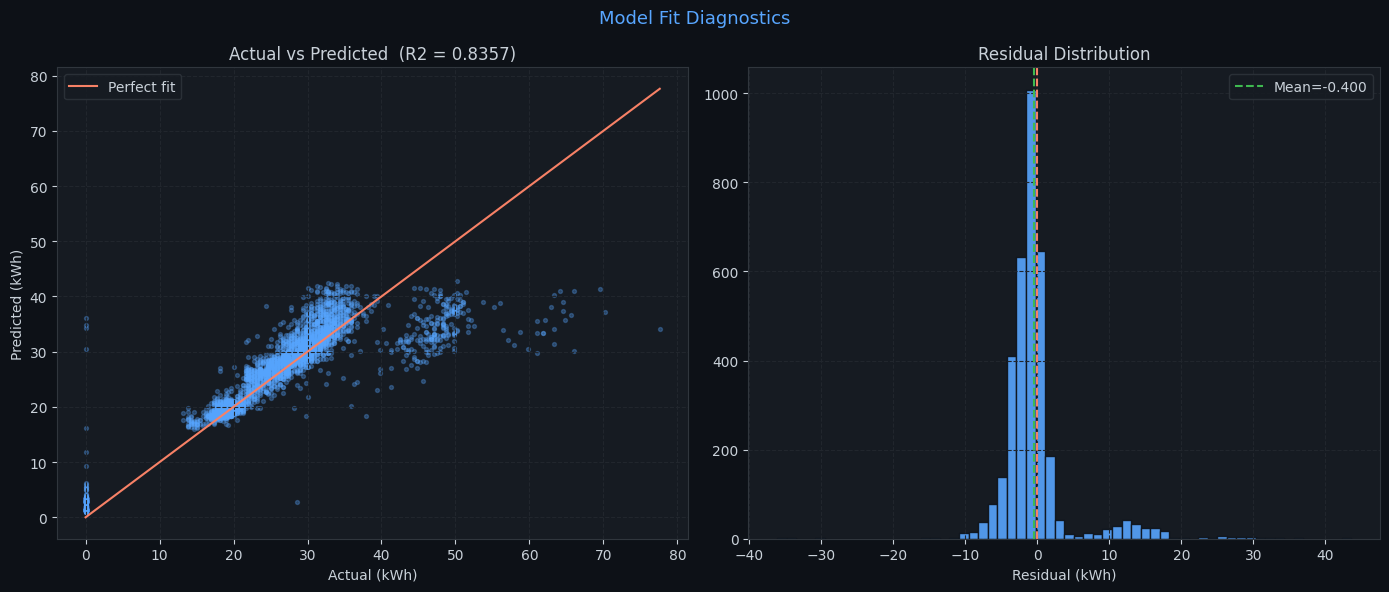

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Fit Diagnostics', fontsize=13, color=ACCENT)

ax1.scatter(y_test, y_pred_tune, alpha=0.3, s=8, color=ACCENT)
mn, mx = min(y_test.min(), y_pred_tune.min()), max(y_test.max(), y_pred_tune.max())
ax1.plot([mn, mx], [mn, mx], color=WARN, linewidth=1.5, label='Perfect fit')
ax1.set_title(f'Actual vs Predicted  (R2 = {r2_tune:.4f})')
ax1.set_xlabel('Actual (kWh)'); ax1.set_ylabel('Predicted (kWh)'); ax1.legend(); ax1.grid(True)

ax2.hist(residuals, bins=60, color=ACCENT, edgecolor='#0d1117', alpha=0.9)
ax2.axvline(0, color=WARN, linestyle='--')
ax2.axvline(residuals.mean(), color=ACCENT2, linestyle='--',
            label=f'Mean={residuals.mean():.3f}')
ax2.set_title('Residual Distribution')
ax2.set_xlabel('Residual (kWh)'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('model_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 10. HVAC Decision Logic

The electricity forecast drives HVAC **setpoints** and **mode** commands sent to the ESP32.


In [18]:
def hvac_command(predicted_kwh, air_temp, hour, is_weekend, occupancy=1):
    """Convert ML electricity forecast + sensor readings into HVAC commands."""
    school_hours = (8 <= hour <= 17) and not is_weekend

    if not occupancy and not school_hours:
        return {'mode':'STANDBY','setpoint_cool':28.0,'setpoint_heat':15.0,
                'fan_speed':'OFF','demand_kWh':round(predicted_kwh,3),
                'status':'Unoccupied - HVAC in standby'}

    if predicted_kwh > 60:
        if air_temp > 22:
            return {'mode':'COOL_SETBACK','setpoint_cool':26.0,'setpoint_heat':18.0,
                    'fan_speed':'LOW','demand_kWh':round(predicted_kwh,3),
                    'status':'High demand - cooling setback active'}
        else:
            return {'mode':'HEAT_SETBACK','setpoint_cool':24.0,'setpoint_heat':17.0,
                    'fan_speed':'LOW','demand_kWh':round(predicted_kwh,3),
                    'status':'High demand - heating setback active'}

    if air_temp >= 26:
        return {'mode':'COOL','setpoint_cool':22.0,'setpoint_heat':18.0,
                'fan_speed':'HIGH' if air_temp > 30 else 'MEDIUM',
                'demand_kWh':round(predicted_kwh,3),'status':'Cooling mode - occupied comfort'}

    if air_temp <= 18:
        return {'mode':'HEAT','setpoint_cool':24.0,'setpoint_heat':21.0,
                'fan_speed':'MEDIUM','demand_kWh':round(predicted_kwh,3),
                'status':'Heating mode - occupied comfort'}

    return {'mode':'VENTILATE','setpoint_cool':24.0,'setpoint_heat':20.0,
            'fan_speed':'LOW','demand_kWh':round(predicted_kwh,3),
            'status':'Comfortable - ventilation only'}


test_df = df.iloc[split_idx:].reset_index(drop=True)
test_df['predicted_electricity'] = y_pred_tune

hvac_results = test_df.apply(
    lambda row: hvac_command(
        row['predicted_electricity'], row['airTemperature'],
        int(row['hour']), int(row['is_weekend']), occupancy=1), axis=1
).apply(pd.Series)

test_df = pd.concat([
    test_df[['timestamp','electricity','predicted_electricity','airTemperature','hour','is_weekend']],
    hvac_results
], axis=1)

print('='*60)
print('SAMPLE HVAC COMMANDS (first 10 test hours)')
print('='*60)
print(test_df[['timestamp','airTemperature','hour','electricity',
               'predicted_electricity','mode','setpoint_cool',
               'setpoint_heat','fan_speed']].head(10).to_string())
print()
print('HVAC Mode Distribution:')
print(test_df['mode'].value_counts().to_string())


SAMPLE HVAC COMMANDS (first 10 test hours)
            timestamp  airTemperature  hour  electricity  predicted_electricity       mode  setpoint_cool  setpoint_heat fan_speed
0 2017-08-09 06:00:00            16.1     6      19.6954              19.123188       HEAT           24.0           21.0    MEDIUM
1 2017-08-09 07:00:00            19.4     7      20.0816              19.444914  VENTILATE           24.0           20.0       LOW
2 2017-08-09 08:00:00            22.2     8      20.8540              19.529258  VENTILATE           24.0           20.0       LOW
3 2017-08-09 09:00:00            25.0     9      23.9434              23.421025  VENTILATE           24.0           20.0       LOW
4 2017-08-09 10:00:00            26.1    10      27.4191              26.285636       COOL           22.0           18.0    MEDIUM
5 2017-08-09 11:00:00            27.2    11      27.8053              31.008195       COOL           22.0           18.0    MEDIUM
6 2017-08-09 12:00:00            27.2   

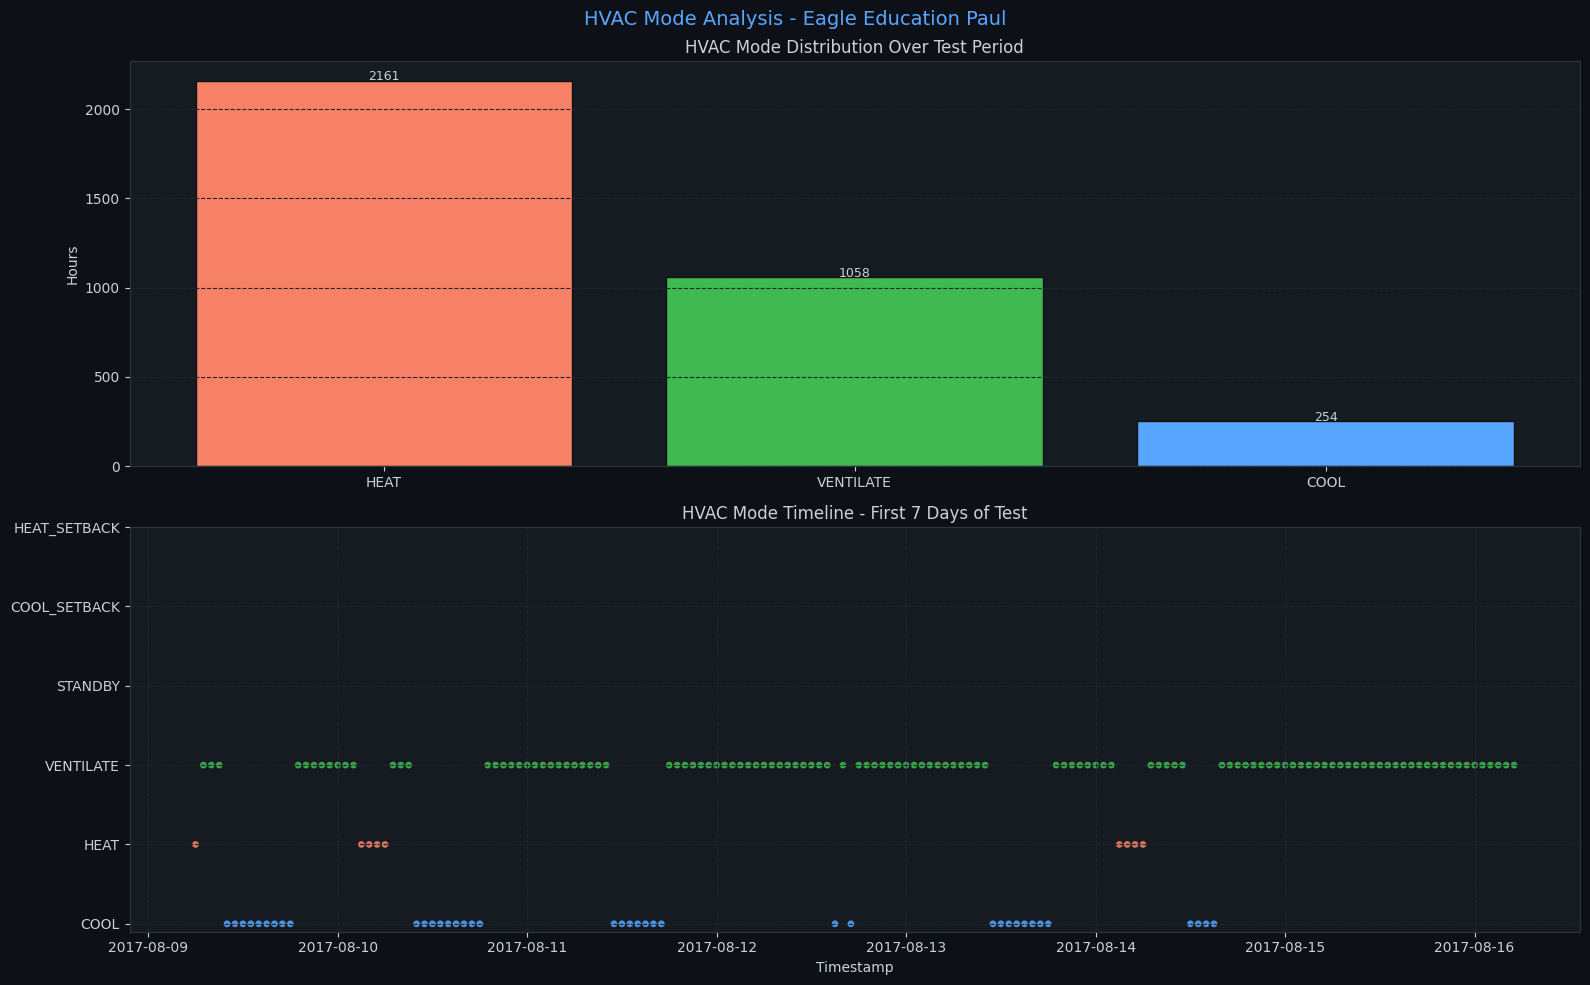

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('HVAC Mode Analysis - Eagle Education Paul', fontsize=14, color=ACCENT)

mode_colors = {'COOL':'#58a6ff','HEAT':'#f78166','VENTILATE':'#3fb950',
               'STANDBY':'#8b949e','COOL_SETBACK':'#d2a8ff','HEAT_SETBACK':'#ffa657'}

counts = test_df['mode'].value_counts()
ax1.bar(counts.index, counts.values,
        color=[mode_colors.get(m, ACCENT) for m in counts.index], edgecolor='#0d1117')
ax1.set_title('HVAC Mode Distribution Over Test Period')
ax1.set_ylabel('Hours'); ax1.grid(True, axis='y')
for i, (m, v) in enumerate(counts.items()):
    ax1.text(i, v+1, str(v), ha='center', fontsize=9, color='#c9d1d9')

sample   = test_df.iloc[:168]
mode_map = {m: i for i, m in enumerate(mode_colors.keys())}
ax2.scatter(sample['timestamp'], sample['mode'].map(mode_map),
            c=[mode_colors.get(m, ACCENT) for m in sample['mode']], s=15, alpha=0.8)
ax2.set_yticks(list(mode_map.values()))
ax2.set_yticklabels(list(mode_map.keys()))
ax2.set_title('HVAC Mode Timeline - First 7 Days of Test')
ax2.set_xlabel('Timestamp'); ax2.grid(True)

plt.tight_layout()
plt.savefig('hvac_mode_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 11. Save Model & Test Predictions


In [20]:
MODEL_PATH = 'random_forest_energy_model.pkl'
joblib.dump(rf_tuned, MODEL_PATH)
print('='*40)
print('MODEL SAVED')
print('='*40)
print(f'{MODEL_PATH}')

CSV_PATH = 'test_predictions.csv'
test_df.to_csv(CSV_PATH, index=False)
print(f'{CSV_PATH} saved successfully!')

with open('model_features.json', 'w') as f:
    json.dump({
        'features': FEATURE_COLS, 'target': TARGET_COL,
        'mae': round(mae_tune,4), 'rmse': round(rmse_tune,4), 'r2': round(r2_tune,4)
    }, f, indent=2)
print('model_features.json saved!')


MODEL SAVED
random_forest_energy_model.pkl
test_predictions.csv saved successfully!
model_features.json saved!


## 12. Final Interpretation


In [21]:
print()
print('='*40)
print('FINAL INTERPRETATION')
print('='*40)
print()
print(f'The tuned Random Forest explains approximately {r2_tune*100:.2f}% of the variation in building electricity demand.')
print()
print(f'Average absolute prediction error (MAE): {mae_tune:.4f}')
print()
print(f'RMSE: {rmse_tune:.4f}')
print()
if rmse_tune > mae_tune:
    print('RMSE is higher than MAE, indicating that some larger prediction errors are present.')
print()
print('Top 3 most important features:')
for rank, (feat, imp) in enumerate(list(importances.head(3).items()), 1):
    print(f'  {rank}. {feat} ({imp:.6f})')
print()
print('HVAC Integration:')
print('  Predictions feed directly into hvac_command() function.')
print('  ESP32 reads sensor data -> sends to Python API -> receives HVAC mode + setpoints.')
print()
print('='*40)
print('ML MODEL TRAINING COMPLETED')
print('='*40)



FINAL INTERPRETATION

The tuned Random Forest explains approximately 83.57% of the variation in building electricity demand.

Average absolute prediction error (MAE): 2.8441

RMSE: 4.9640

RMSE is higher than MAE, indicating that some larger prediction errors are present.

Top 3 most important features:
  1. electricity_lag_1 (0.419829)
  2. elec_roll_mean_3 (0.238529)
  3. elec_roll_mean_6 (0.089491)

HVAC Integration:
  Predictions feed directly into hvac_command() function.
  ESP32 reads sensor data -> sends to Python API -> receives HVAC mode + setpoints.

ML MODEL TRAINING COMPLETED


---
## 13. ESP32 Arduino Code

| Sensor | Pin | Measures |
|---|---|---|
| DHT22 | GPIO 4 | Temperature, Humidity |
| BMP280 | I2C (21/22) | Barometric Pressure |
| MQ-135 | GPIO 34 (ADC) | Air Quality / CO2 |
| PIR HC-SR501 | GPIO 5 | Occupancy |
| Relay Module | GPIO 26/27/25 | HVAC ON/OFF control |


In [ ]:
arduino_sketch = '''
// ============================================================
// ESP32 HVAC Controller - Eagle Education Paul
// Sensors: DHT22, BMP280, MQ-135, PIR HC-SR501
// POST sensor JSON to Python ML API, receive HVAC mode
// ============================================================
#include <WiFi.h>
#include <HTTPClient.h>
#include <ArduinoJson.h>
#include <DHT.h>
#include <Wire.h>
#include <Adafruit_BMP280.h>

#define DHT_PIN     4
#define DHT_TYPE    DHT22
#define MQ135_PIN   34
#define PIR_PIN     5
#define RELAY_COOL  26
#define RELAY_HEAT  27
#define RELAY_FAN   25

const char* SSID     = "YOUR_WIFI_SSID";
const char* PASSWORD = "YOUR_WIFI_PASSWORD";
const char* API_URL  = "http://192.168.1.100:8000/predict";

DHT dht(DHT_PIN, DHT_TYPE);
Adafruit_BMP280 bmp;
String current_mode = "STANDBY";

void setup() {
  Serial.begin(115200);
  dht.begin();
  Wire.begin(21, 22);
  bmp.begin(0x76);
  pinMode(PIR_PIN, INPUT);
  pinMode(RELAY_COOL, OUTPUT);
  pinMode(RELAY_HEAT, OUTPUT);
  pinMode(RELAY_FAN,  OUTPUT);
  digitalWrite(RELAY_COOL, HIGH);
  digitalWrite(RELAY_HEAT, HIGH);
  digitalWrite(RELAY_FAN,  HIGH);
  WiFi.begin(SSID, PASSWORD);
  Serial.print("Connecting");
  while (WiFi.status() != WL_CONNECTED) { delay(500); Serial.print("."); }
  Serial.println("Connected: " + WiFi.localIP().toString());
}

struct SensorData { float temp, hum, pres; int aq, occ; };

SensorData readSensors() {
  SensorData s;
  s.temp = dht.readTemperature();
  s.hum  = dht.readHumidity();
  s.pres = bmp.readPressure() / 100.0F;
  s.aq   = analogRead(MQ135_PIN);
  s.occ  = digitalRead(PIR_PIN);
  if (isnan(s.temp)) s.temp = 22.0;
  if (isnan(s.hum))  s.hum  = 50.0;
  return s;
}

int getCurrentHour() { return (millis() / 3600000UL) % 24; }

String queryMLAPI(SensorData& s) {
  if (WiFi.status() != WL_CONNECTED) return "STANDBY";
  HTTPClient http;
  http.begin(API_URL);
  http.addHeader("Content-Type", "application/json");
  StaticJsonDocument<256> doc;
  doc["air_temperature"] = s.temp;
  doc["humidity"]        = s.hum;
  doc["pressure"]        = s.pres;
  doc["air_quality"]     = s.aq;
  doc["occupancy"]       = s.occ;
  doc["hour"]            = getCurrentHour();
  doc["building"]        = "Eagle_education_Paul";
  String body; serializeJson(doc, body);
  int code = http.POST(body);
  String mode = "STANDBY";
  if (code == HTTP_CODE_OK) {
    StaticJsonDocument<512> resp;
    deserializeJson(resp, http.getString());
    mode = resp["mode"].as<String>();
    Serial.printf("[API] Mode:%s Cool:%.1f Heat:%.1f kWh:%.2f\n",
      mode.c_str(),(float)resp["setpoint_cool"],(float)resp["setpoint_heat"],(float)resp["demand_kWh"]);
  } else { Serial.printf("[API] Error: %d\n", code); }
  http.end(); return mode;
}

void applyHVAC(String mode) {
  if (mode=="COOL"||mode=="COOL_SETBACK"){
    digitalWrite(RELAY_COOL,LOW); digitalWrite(RELAY_HEAT,HIGH); digitalWrite(RELAY_FAN,LOW);
  } else if (mode=="HEAT"||mode=="HEAT_SETBACK"){
    digitalWrite(RELAY_COOL,HIGH); digitalWrite(RELAY_HEAT,LOW); digitalWrite(RELAY_FAN,LOW);
  } else if (mode=="VENTILATE"){
    digitalWrite(RELAY_COOL,HIGH); digitalWrite(RELAY_HEAT,HIGH); digitalWrite(RELAY_FAN,LOW);
  } else {
    digitalWrite(RELAY_COOL,HIGH); digitalWrite(RELAY_HEAT,HIGH); digitalWrite(RELAY_FAN,HIGH);
  }
}

void loop() {
  SensorData s = readSensors();
  Serial.printf("[Sensors] T:%.1f H:%.1f P:%.1f AQ:%d Occ:%d\n",s.temp,s.hum,s.pres,s.aq,s.occ);
  String mode = queryMLAPI(s);
  applyHVAC(mode);
  Serial.printf("[HVAC] Mode: %s\n\n", mode.c_str());
  delay(60000);
}
'''

with open('esp32_hvac_controller.ino', 'w') as f:
    f.write(arduino_sketch)
print('ESP32 Arduino sketch saved to esp32_hvac_controller.ino')
print('Required libraries: WiFi, HTTPClient, ArduinoJson, DHT, Adafruit_BMP280')


## 14. Python FastAPI Server (ESP32 <-> ML Bridge)


In [ ]:
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, json, numpy as np
from datetime import datetime

app   = FastAPI(title="HVAC ML API - Eagle Education Paul")
model = joblib.load("random_forest_energy_model.pkl")
feats = json.load(open("model_features.json"))["features"]

class Payload(BaseModel):
    air_temperature: float; humidity: float; pressure: float
    air_quality: int; occupancy: int; hour: int
    building: str = "Eagle_education_Paul"

def hvac_cmd(kwh, temp, hour, wknd, occ):
    sch = (8<=hour<=17) and not wknd
    if not occ and not sch:
        return {"mode":"STANDBY","setpoint_cool":28.0,"setpoint_heat":15.0,"fan_speed":"OFF","demand_kWh":round(kwh,3)}
    if kwh>60:
        m="COOL_SETBACK" if temp>22 else "HEAT_SETBACK"
        return {"mode":m,"setpoint_cool":26.0,"setpoint_heat":17.0,"fan_speed":"LOW","demand_kWh":round(kwh,3)}
    if temp>=26:
        return {"mode":"COOL","setpoint_cool":22.0,"setpoint_heat":18.0,
                "fan_speed":"HIGH" if temp>30 else "MEDIUM","demand_kWh":round(kwh,3)}
    if temp<=18:
        return {"mode":"HEAT","setpoint_cool":24.0,"setpoint_heat":21.0,"fan_speed":"MEDIUM","demand_kWh":round(kwh,3)}
    return {"mode":"VENTILATE","setpoint_cool":24.0,"setpoint_heat":20.0,"fan_speed":"LOW","demand_kWh":round(kwh,3)}

@app.get("/") 
def root(): return {"status":"running","building":"Eagle_education_Paul"}

@app.post("/predict")
def predict(p: Payload):
    now=datetime.now(); wknd=int(now.weekday()>=5)
    dew=p.air_temperature-(100-p.humidity)/5
    fmap={"airTemperature":p.air_temperature,"dewTemperature":dew,
          "cloudCoverage":0.0,"seaLvlPressure":p.pressure,
          "windDirection":0.0,"windSpeed":0.0,
          "hour":float(p.hour),"day_of_week":float(now.weekday()),
          "month":float(now.month),"is_weekend":float(wknd),"sqm":4008.1}
    vec=np.array([fmap.get(f,0.0) for f in feats]).reshape(1,-1)
    kwh=float(model.predict(vec)[0])
    return hvac_cmd(kwh,p.air_temperature,p.hour,wknd,p.occupancy)
'''

with open('hvac_api.py', 'w') as f:
    f.write(api_code)
print('FastAPI server saved to hvac_api.py')
print()
print('Start server:  uvicorn hvac_api:app --host 0.0.0.0 --port 8000')
print('ESP32 POSTs to: http://<your-pc-ip>:8000/predict')


---
## System Architecture

```
Eagle Education Paul (Classroom 4008 m2)
          |
    [ESP32 Node]
     DHT22  GPIO4  -> Temperature + Humidity
     BMP280 I2C    -> Barometric Pressure
     MQ-135 GPIO34 -> CO2 / Air Quality
     PIR    GPIO5  -> Occupancy
          | HTTP POST (WiFi)
    [FastAPI Server - PC/RPi on LAN]
     random_forest_energy_model.pkl
     hvac_command() HVAC logic
          | JSON: mode + setpoints
    [ESP32 Relay Control]
     GPIO26 -> Cooling relay
     GPIO27 -> Heating relay
     GPIO25 -> Fan relay
```

### HVAC Mode Reference

| Mode | Condition | Cool SP | Heat SP | Fan |
|---|---|---|---|---|
| COOL | Temp >= 26C, occupied | 22C | 18C | MED/HIGH |
| HEAT | Temp <= 18C, occupied | 24C | 21C | MEDIUM |
| VENTILATE | 18C < Temp < 26C | 24C | 20C | LOW |
| COOL_SETBACK | Demand > 60 kWh, hot | 26C | 18C | LOW |
| HEAT_SETBACK | Demand > 60 kWh, cold | 24C | 17C | LOW |
| STANDBY | Unoccupied off-hours | 28C | 15C | OFF |

---
*Eagle_education_Paul HVAC ML Forecasting System*
